# IMT2200 - Análisis PIB y Esperanza de Vida

Notebook generado a partir de los archivos:

- `pib2020-2025.csv`
- `WHO_life_expectancy.csv`

El flujo sigue la estructura típica de la I2: carga de datos, EDA, limpieza, unión de tablas y algunas visualizaciones básicas.

## 1. Importación de librerías

In [1]:
"""En esta sección importamos las librerías que usaremos para el análisis."""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#sns.set(style='whitegrid')

## 2. Carga de datos

In [3]:
# Cargamos los datasets desde archivos CSV
pib = pd.read_csv('data_2025/pib2020-2025.csv')
life = pd.read_csv('data_2025/WHO_life_expectancy.csv')

display(pib.head())
display(life.head())

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


## 3. Inspección inicial

In [4]:
print('--- PIB ---')
display(pib.info())
display(pib.describe())

print('\n--- Esperanza de vida (WHO) ---')
display(life.info())
display(life.describe(include='all'))

--- PIB ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


None

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.940000e+02,1.940000e+02,1.940000e+02,1.920000e+02,1.890000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.220864e+06,2.347886e+06,2.453040e+06,2.573189e+06,2.693421e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.114175e+04,1.265000e+04,1.360450e+04,1.350050e+04,1.421400e+04
50%,3.533450e+04,3.771900e+04,4.156800e+04,4.363100e+04,4.713550e+04,4.782900e+04
75%,2.074810e+05,2.546132e+05,2.746308e+05,2.850355e+05,2.915108e+05,3.032930e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07



--- Esperanza de vida (WHO) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-null  object
 6   Location             24420 non-null  object
 7   Period type          24420 non-null  object
 8   Period               24420 non-null  int64 
 9   Dim1 type            24420 non-null  object
 10  Dim1                 24420 non-null  object
 11  Value                24420 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.2+ MB


None

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
count,24420,24420,24420,24420,24420,24420,24420,24420,24420.000000,24420,24420,24420
unique,2,2,6,6,1,185,185,1,NaN,1,3,9937
top,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,LSO,Lesotho,Year,NaN,Sex,Male,21.8 [21.8-21.9]
freq,12210,12210,6600,6600,24420,132,132,24420,NaN,24420,8140,37
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.500000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.344419,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.500000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN


## 4. Valores nulos

In [5]:
print('Nulos en PIB:')
display(pib.isna().sum())

print('\nNulos en WHO_life_expectancy:')
display(life.isna().sum())

Nulos en PIB:


Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64


Nulos en WHO_life_expectancy:


IndicatorCode          0
Indicator              0
ParentLocationCode     0
ParentLocation         0
Location type          0
SpatialDimValueCode    0
Location               0
Period type            0
Period                 0
Dim1 type              0
Dim1                   0
Value                  0
dtype: int64

## 5. Limpieza de `pib`

In [6]:
# Eliminamos filas completamente nulas (si existieran)
pib_clean = pib.dropna(how='all').copy()

# Imputamos valores numéricos faltantes de años con el promedio de cada columna
cols_years = ['2020','2021','2022','2023','2024','2025']
for col in cols_years:
    if col in pib_clean.columns:
        pib_clean[col] = pib_clean[col].astype(float)
        pib_clean[col] = pib_clean[col].fillna(pib_clean[col].mean())

pib_clean.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136.0,14278.0,14501.0,17248.0,575687.072917,599141.449735
1,Albania,15271.0,18086.0,19185.0,23388.0,27259.000000,28372.000000
2,Algeria,164774.0,185850.0,225709.0,247789.0,264913.000000,268885.000000
3,Andorra,2885.0,3325.0,3376.0,3786.0,4038.000000,4035.000000
4,Angola,66521.0,84375.0,142442.0,109764.0,115946.000000,113343.000000


## 6. Limpieza de `life` (WHO)

Nos quedaremos con:

- Un solo año de referencia (por ejemplo 2021)
- Sexo: `Both sexes`
- Las columnas relevantes: país, año y valor numérico de esperanza de vida.

In [7]:
# Filtramos por año y sexo
life_2021 = life[(life['Period'] == 2021) & (life['Dim1'] == 'Both sexes')].copy()

# Nos quedamos solo con columnas relevantes
life_2021 = life_2021[['Location','Period','Value']].copy()

# La columna Value viene como '51.5 [50.5-52.6]'. Nos quedamos solo con el número antes del espacio
life_2021['life_expectancy'] = life_2021['Value'].str.split().str[0].astype(float)

# Renombramos Location a Country para poder hacer merge con el PIB
life_clean = life_2021.rename(columns={'Location':'Country'})[['Country','Period','life_expectancy']]

life_clean.head()

,Country,Period,life_expectancy
2,Lesotho,2021,51.5
5,Central African Republic,2021,52.3
6,Somalia,2021,54.0
8,Eswatini,2021,54.6
18,Mozambique,2021,57.7


## 7. Unión (merge) de PIB con esperanza de vida

Ahora sí las dos tablas tienen la columna `Country`, por lo que podemos hacer el `merge` sin error de `KeyError`. Uniremos usando un `inner join`, es decir, solo los países que aparezcan en ambos datasets.

In [8]:
merged = pib_clean.merge(life_clean, on='Country', how='inner')
merged.head()

,Country,2020,2021,2022,2023,2024,2025,Period,life_expectancy
0,Afghanistan,20136.0,14278.0,14501.0,17248.0,575687.072917,599141.449735,2021,59.1
1,Afghanistan,20136.0,14278.0,14501.0,17248.0,575687.072917,599141.449735,2021,13.7
2,Albania,15271.0,18086.0,19185.0,23388.0,27259.000000,28372.000000,2021,76.4
3,Albania,15271.0,18086.0,19185.0,23388.0,27259.000000,28372.000000,2021,19.9
4,Algeria,164774.0,185850.0,225709.0,247789.0,264913.000000,268885.000000,2021,76.0


## 8. EDA sobre el dataset combinado

In [9]:
merged.describe()

,2020,2021,2022,2023,2024,2025,Period,life_expectancy
count,3.220000e+02,3.220000e+02,3.220000e+02,3.220000e+02,3.220000e+02,3.220000e+02,322.0,322.000000
mean,3.397331e+05,3.939320e+05,4.016986e+05,4.159017e+05,4.310566e+05,4.496628e+05,2021.0,44.915217
std,1.331124e+06,1.570583e+06,1.567000e+06,1.580591e+06,1.620124e+06,1.661279e+06,0.0,26.848034
min,2.220000e+02,2.850000e+02,2.710000e+02,2.890000e+02,3.080000e+02,3.120000e+02,2021.0,12.000000
25%,1.140800e+04,1.247500e+04,1.395700e+04,1.577200e+04,1.742000e+04,1.788500e+04,2021.0,18.025000
50%,3.583800e+04,4.084000e+04,4.444200e+04,4.619200e+04,5.278400e+04,5.610200e+04,2021.0,39.050000
75%,1.912100e+05,2.262680e+05,2.452030e+05,2.674820e+05,2.848100e+05,3.039450e+05,2021.0,72.100000
max,1.510336e+07,1.819080e+07,1.830782e+07,1.827035e+07,1.874801e+07,1.923170e+07,2021.0,84.500000


### 8.1 Relación entre PIB 2021 y esperanza de vida 2021

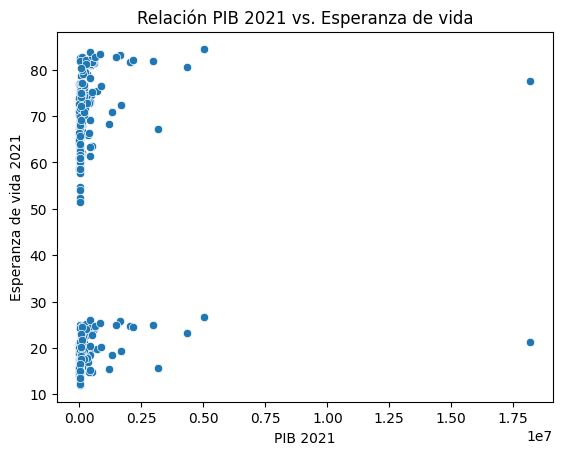

In [10]:
plt.figure()
sns.scatterplot(data=merged, x='2021', y='life_expectancy')
plt.xlabel('PIB 2021')
plt.ylabel('Esperanza de vida 2021')
plt.title('Relación PIB 2021 vs. Esperanza de vida')
plt.show()

### 8.2 Países con mayor PIB en 2021

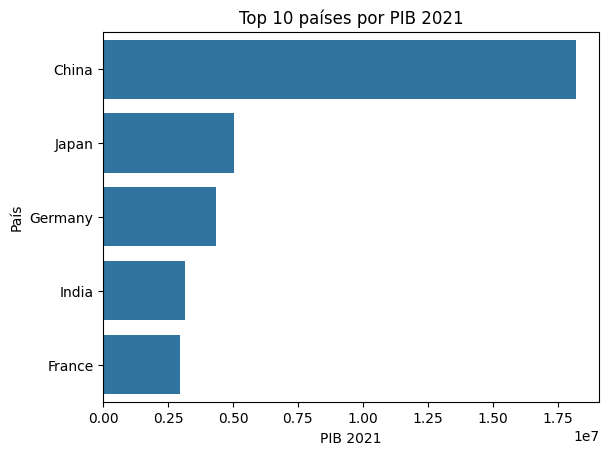

In [11]:
top_pib = merged.sort_values('2021', ascending=False).head(10)
plt.figure()
sns.barplot(data=top_pib, x='2021', y='Country')
plt.xlabel('PIB 2021')
plt.ylabel('País')
plt.title('Top 10 países por PIB 2021')
plt.show()

### 8.3 Distribución de la esperanza de vida

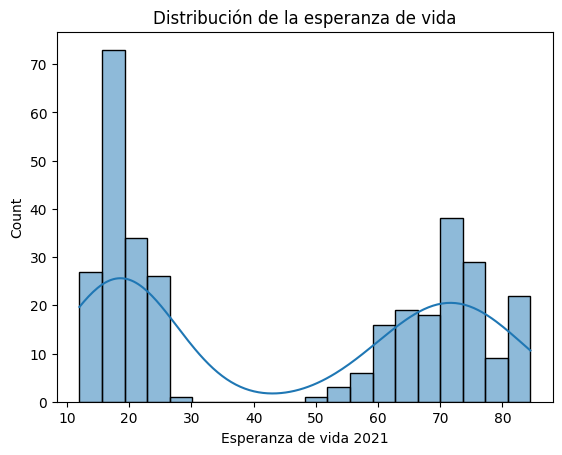

In [12]:
plt.figure()
sns.histplot(data=merged, x='life_expectancy', bins=20, kde=True)
plt.xlabel('Esperanza de vida 2021')
plt.title('Distribución de la esperanza de vida')
plt.show()

## 9. Comentarios finales

- Revisar si hay países con valores extremos de PIB o esperanza de vida.
- Discutir si parece haber relación positiva entre PIB y esperanza de vida.
- Este notebook se puede ampliar con más años, normalización de variables, correlaciones, etc., siguiendo el estilo de la I2.